In [4]:
import numpy as np
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('.')  # 添加当前目录到路径

from h2_excited_states import (
    setup_h2_system,
    compute_ground_state,
    compute_1st_excited_state,
    compute_2nd_excited_state,
    compute_all_excited_states,
    plot_convergence,
    plot_energy_levels
)
bond_distance = np.round(np.linspace(0.2,1.4,15),2)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/utils/dispatch.py:25: FutureWarning: 
The variables `nk.utils.dispatch.{TrueT|FalseT|Bool}` are deprecated. Their usages
should instead be replaced by the following objects:

    `TrueT` should be replaced by `typing.Literal[True]`
    `FalseT` should be replaced by `typing.Literal[False]`
    `Bool` should be replaced by `bool`

  _warn_deprecation(
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/driver/vmc_common.py:33: FutureWarning: 

            `nk.driver.vmc_common is deprecated and the functionality removed.   

If you imported `nk.driver.vmc_common`, you must reimplement that functionality yourself.


  warn_deprecation(


In [2]:
model_rbm = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)

In [3]:
bond_distance[0]=1.74

In [5]:
# 步骤1：设置H2分子系统
mol, ha, hi, sampler, e_fci_all, E_fci = setup_h2_system(bond_length=bond_distance[0])

Hartree-Fock能量: 0.16417501 Ha
FCI基态能量: 0.15748213 Ha

FCI所有能级:
  E0 (基态) = 0.15748213 Ha
  E1 (第1激发态) = 1.83993163 Ha
  E2 (第2激发态) = 2.15587705 Ha
  E3 (第3激发态) = 3.89282200 Ha

Hilbert空间维度: 4
空间轨道数: 2
电子数: 2


In [5]:
# 步骤2：计算基态
vs_gs, final_energy_gs, gs_params = compute_ground_state(
    ha=ha,
    sampler=sampler,
    n_iter=1000,
    model=model_rbm,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=50,
    n_samples=1024,
    output_path=f'Data_H2/RBM/ground_state_{bond_distance[0]}A'
)


开始计算基态...


100%|██████████| 1000/1000 [01:17<00:00, 12.88it/s, Energy=-9.673e-01+1.508e-10j ± 9.490e-11 [σ²=4.621e-18, R̂=1.3984]]   

基态能量: -0.96730577 Ha


In [6]:
# 步骤3：计算第一激发态
vs_ex1, final_energy_ex1, ex1_params, vs_gs = compute_1st_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    e_fci=E_fci,
    n_iter=1000,
    model=model_rbm,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=50,
    n_samples=1024,
    shift=2.5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/RBM/excited_state_1_{bond_distance[0]}A'
)


开始计算第一激发态 (shift=2.5)...


100%|██████████| 1000/1000 [02:42<00:00,  6.16it/s, Energy=-9.131e-01+1.601e-06j ± 6.939e-17 [σ²=2.310e-12, R̂=1.0021]]   

第一激发态能量: -0.91306096 Ha
激发能: 0.05424480 Ha


In [7]:
# 步骤4：计算第二激发态
vs_ex2, final_energy_ex2, ex2_params, vs_gs, vs_ex1_loaded = compute_2nd_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    ex1_params=ex1_params,
    e_fci=E_fci,
    n_iter=1000,
    model=model_rbm,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=50,
    n_samples=1024,
    shift=5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/RBM/excited_state_2_{bond_distance[0]}A'
)


开始计算第二激发态 (shift=5)...


100%|██████████| 1000/1000 [04:07<00:00,  4.04it/s, Energy=-0.3864-0.0007j ± 0.0032 [σ²=0.0225, R̂=1.0156]]           

第二激发态能量: -0.38637851 Ha
激发能: 0.58092726 Ha


In [8]:
# 步骤4：计算第二激发态
vs_ex2_lamada_5, final_energy_ex2_lamada_5, ex2_params_lamada_5, vs_gs, vs_ex1_loaded = compute_2nd_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    ex1_params=ex1_params,
    e_fci=E_fci,
    n_iter=1000,
    model=model_rbm,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=50,
    n_samples=1024,
    shift=5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/RBM/excited_state_2_{bond_distance[0]}A_lamada_5'
)


开始计算第二激发态 (shift=5)...


100%|██████████| 1000/1000 [04:09<00:00,  4.01it/s, Energy=-0.255350+0.000045j ± 0.000097 [σ²=0.000526, R̂=0.9789]]   

第二激发态能量: -0.25535037 Ha
激发能: 0.71195540 Ha


In [6]:
import json
import matplotlib.pyplot as plt
with open('./Data_H2/RBM/ground_state_1.74A.log', 'r') as f:
    data_gs = json.load(f)

with open('./Data_H2/RBM/excited_state_1_1.74A.log', 'r') as f:
    data_ex1 = json.load(f)
    
with open('./Data_H2/RBM/excited_state_2_1.74A.log', 'r') as f:
    data_ex2 = json.load(f)
iter_gs = data_gs["Energy"]["iters"]
iter_ex1 = data_ex1["Energy"]["iters"]
iter_ex2 = data_ex2["Energy"]["iters"]



energy_gs = data_gs["Energy"]["Mean"]['real']
energy_ex1 = data_ex1["Energy"]["Mean"]['real']
energy_ex1[0]=energy_ex1[1]
energy_ex2 = data_ex2["Energy"]["Mean"]['real']
energy_ex2[0]=energy_ex2[1]


In [10]:
e_fci_all

array([-0.96730577, -0.91306114, -0.42410252, -0.35953957])

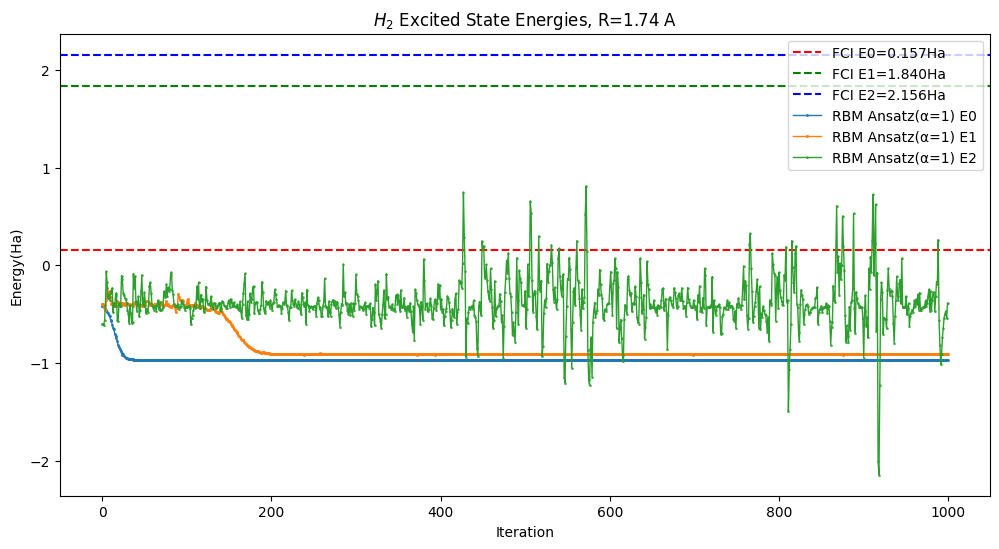

In [9]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
plt.axhline(e_fci_all[0], color='r', linestyle='--', label=f'FCI E0={e_fci_all[0]:.3f}Ha')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label=f'FCI E1={e_fci_all[1]:.3f}Ha')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label=f'FCI E2={e_fci_all[2]:.3f}Ha')
plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2', linewidth=1, markersize=1)
plt.legend()


In [13]:
with open('./Data_H2/RBM/excited_state_2_1.74A_lamada_5.log', 'r') as f:
    data_ex2_lamada_5 = json.load(f)
iter_ex2_lamada_5 = data_ex2_lamada_5['Energy']['iters']
energy_ex2_lamada_5 = data_ex2_lamada_5['Energy']['Mean']['real']

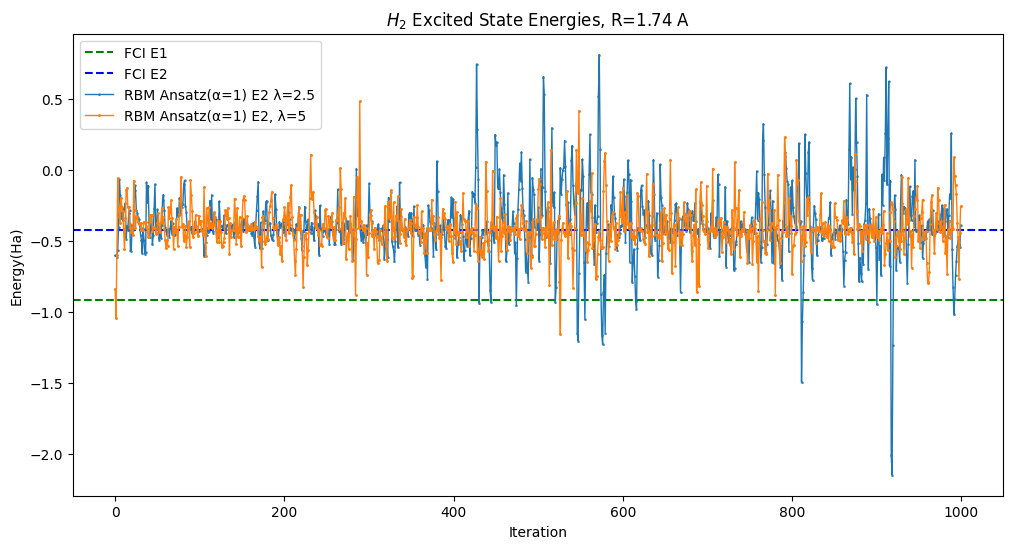

In [15]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
#plt.axhline(e_fci_all[0], color='r', linestyle='--', label='FCI E0')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label='FCI E1')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label='FCI E2')
#plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
# plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2 λ=2.5', linewidth=1, markersize=1)
plt.plot(iter_ex2_lamada_5, energy_ex2_lamada_5, 'D-', label='RBM Ansatz(α=1) E2, λ=5', linewidth=1, markersize=1)
plt.legend()
